In [1]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = ""
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                caption = f.read().strip()

        return image, label, caption.lower()

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

cub_root_dir = '/kaggle/input/datasets/nmpogg/cub-caption/CUB_200_2011'

train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


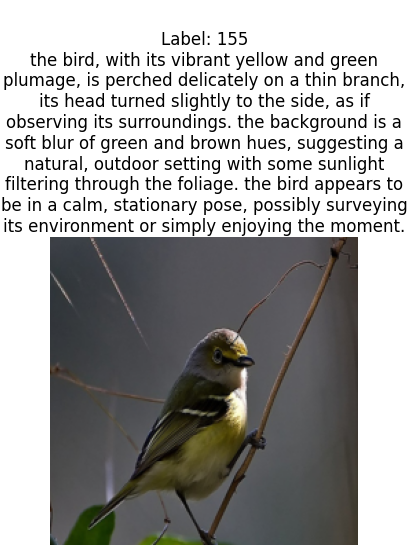

In [3]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"Label: {label_id}\n{caption_text}")

In [4]:
import torch
import torch.nn as nn
from torchvision import models

class BirdClassifierResNet50(nn.Module):
    def __init__(self, num_classes=200, freeze_backbone=False):
        super(BirdClassifierResNet50, self).__init__()

        self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

    def get_optimizer(self, base_lr=1e-5, head_lr=1e-3, weight_decay=1e-4):

        # head param
        head_params = list(self.model.fc.parameters())
        head_param_ids = [id(p) for p in head_params]

        # backbone param
        backbone_params = [
            p for p in self.model.parameters()
            if id(p) not in head_param_ids and p.requires_grad
        ]

        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': base_lr},
            {'params': head_params, 'lr': head_lr}
        ], weight_decay=weight_decay)

        return optimizer

    def predict_image(self, img_tensor, device):

        self.eval()
        with torch.no_grad():
            # Đảm bảo ảnh có batch dimension, ví dụ: từ [3, 224, 224] thành [1, 3, 224, 224]
            if len(img_tensor.shape) == 3:
                img_tensor = img_tensor.unsqueeze(0)

            img_tensor = img_tensor.to(device)
            outputs = self(img_tensor)

            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted_class = torch.max(probabilities, 1)

        return predicted_class.item(), confidence.item()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BirdClassifierResNet50(num_classes=200, freeze_backbone=False).to(device)

optimizer = model.get_optimizer(base_lr=1e-5, head_lr=1e-3)

criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


In [6]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 50
patience = 3
epochs_no_improve = 0
best_test_acc = 0.0


print("BẮT ĐẦU HUẤN LUYỆN...")

for epoch in range(num_epochs):
    # train
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for inputs, labels, _ in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train

    # eval
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    test_pbar = tqdm(test_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Test ", leave=False)

    with torch.no_grad():
        for inputs, labels, _ in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = test_loss / len(test_loader.dataset)
    epoch_test_acc = 100 * correct_test / total_test

    if scheduler is not None:
        scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f}, Acc: {epoch_test_acc:.2f}%")

    if epoch_test_acc > best_test_acc:
        print(f"Best acc: {epoch_test_acc:.2f}%. Đã lưu weights")
        best_test_acc = epoch_test_acc
        epochs_no_improve = 0
        # save
        torch.save(model.state_dict(), "best_resnet50_cub.pth")
    else:
        epochs_no_improve += 1
        print(f"Test acc không tăng, early stopping: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"EARLY STOPPING. Đã dừng huấn luyện ở epoch {epoch+1}.")
            break

print("Hoàn thành quá trình huấn luyện!")

BẮT ĐẦU HUẤN LUYỆN...


Epoch [1/50] Train Loss: 3.6453, Acc: 26.06% | Test Loss: 1.8419, Acc: 55.64%
Best acc: 55.64%. Đã lưu weights


Epoch [2/50] Train Loss: 1.1275, Acc: 71.82% | Test Loss: 1.2418, Acc: 66.57%
Best acc: 66.57%. Đã lưu weights


Epoch [3/50] Train Loss: 0.6214, Acc: 84.30% | Test Loss: 1.0612, Acc: 70.66%
Best acc: 70.66%. Đã lưu weights


Epoch [4/50] Train Loss: 0.3813, Acc: 91.51% | Test Loss: 1.0032, Acc: 72.40%
Best acc: 72.40%. Đã lưu weights


...

Epoch [17/50] Train Loss: 0.0210, Acc: 99.82% | Test Loss: 1.0228, Acc: 74.96%
Test acc không tăng, early stopping: 1/3


Epoch [18/50] Train Loss: 0.0198, Acc: 99.77% | Test Loss: 1.0111, Acc: 76.03%
Best acc: 76.03%. Đã lưu weights


Epoch [19/50] Train Loss: 0.0157, Acc: 99.82% | Test Loss: 1.0570, Acc: 74.97%
Test acc không tăng, early stopping: 1/3


Epoch [20/50] Train Loss: 0.0165, Acc: 99.73% | Test Loss: 1.0394, Acc: 75.63%
Test acc không tăng, early stopping: 2/3


Epoch [21/50] Train Loss: 0.0128, Acc: 99.88% | Test Loss: 1.0654, Acc: 75.16%
Test acc không tăng, early stopping: 3/3
EARLY STOPPING. Đã dừng huấn luyện ở epoch 21.
Hoàn thành quá trình huấn luyện!


In [7]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def evaluate_retrieval_from_resnet(model, dataloader, device, k_values=[1, 3, 5, 7, 10, 20]):
    model.eval()
    all_features = []
    all_labels = []
    
    print("1. Đang trích xuất đặc trưng từ ResNet50 (Bỏ qua lớp phân loại)...")
    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader, desc="Extracting"):
            images = images.to(device)
            
            # --- CÁCH LẤY ĐẶC TRƯNG CHO TORCHVISION RESNET50 ---
            x = images
            
            # Lặp qua tất cả các khối (layers) của ResNet50
            for name, module in model.model.named_children():
                if name == 'fc': 
                    # Dừng lại ngay trước khi vào lớp Fully Connected (lớp phân loại)
                    break
                x = module(x)
            
            # Lúc này x (sau lớp avgpool) có kích thước [Batch, 2048, 1, 1]
            # Ta duỗi (Flatten) tensor thành vector 1 chiều: [Batch, 2048]
            features = torch.flatten(x, 1)
            
            # Chuẩn hóa L2 để tính Cosine Similarity bằng Dot Product
            features = F.normalize(features, p=2, dim=1)
            
            all_features.append(features.cpu())
            all_labels.append(labels)
            
    all_features = torch.cat(all_features, dim=0) # [N, 2048]
    all_labels = torch.cat(all_labels, dim=0)     # [N]
    
    N = all_features.size(0)
    
    print("2. Đang tính ma trận khoảng cách (Cosine Similarity)...")
    similarity_matrix = torch.mm(all_features, all_features.t())
    
    # Bỏ qua việc tự so sánh với chính nó
    similarity_matrix.fill_diagonal_(-float('inf'))
    
    max_k = max(k_values)
    _, top_k_indices = similarity_matrix.topk(max_k, dim=1)
    top_k_labels = all_labels[top_k_indices]
    
    print("3. Đang tính toán Metrics (Precision, Recall, mAP)...")
    results = {k: {'Precision': 0.0, 'Recall': 0.0, 'mAP': 0.0} for k in k_values}
    
    for i in range(N):
        query_label = all_labels[i].item()
        retrieved_labels = top_k_labels[i].numpy()
        
        # Tổng số ảnh cùng class (không tính chính nó)
        total_relevant = (all_labels == query_label).sum().item() - 1 
        if total_relevant == 0:
            continue
            
        relevance_array = (retrieved_labels == query_label)
        
        for k in k_values:
            rel_k = relevance_array[:k]
            hits = rel_k.sum()
            
            results[k]['Precision'] += hits / k
            results[k]['Recall'] += hits / total_relevant
            
            if hits > 0:
                precisions = [rel_k[:j+1].sum() / (j+1) for j in range(k) if rel_k[j]]
                results[k]['mAP'] += sum(precisions) / min(k, total_relevant)
                
    for k in k_values:
        results[k]['Precision'] /= N
        results[k]['Recall'] /= N
        results[k]['mAP'] /= N
        
    return results

# Chạy đánh giá (Truyền đúng model ResNet50 đã train)
k_vals = [1, 3, 5, 7, 10, 20]
metrics = evaluate_retrieval_from_resnet(model, test_loader, device, k_values=k_vals)

# In kết quả
print("\n" + "="*65)
print(f"{'K':<5} | {'Precision@K':<15} | {'Recall@K':<15} | {'mAP@K':<15}")
print("-" * 65)
for k in k_vals:
    p = metrics[k]['Precision']
    r = metrics[k]['Recall']
    m = metrics[k]['mAP']
    print(f"{k:<5} | {p:<15.4f} | {r:<15.4f} | {m:<15.4f}")
print("="*65)

1. Đang trích xuất đặc trưng từ ResNet50 (Bỏ qua lớp phân loại)...


Extracting: 100%|██████████| 182/182 [00:25<00:00,  7.01it/s]


2. Đang tính ma trận khoảng cách (Cosine Similarity)...
3. Đang tính toán Metrics (Precision, Recall, mAP)...

K     | Precision@K     | Recall@K        | mAP@K          
-----------------------------------------------------------------
1     | 0.6262          | 0.0224          | 0.6262         
3     | 0.5821          | 0.0625          | 0.5362         
5     | 0.5484          | 0.0980          | 0.4825         
7     | 0.5224          | 0.1305          | 0.4452         
10    | 0.4890          | 0.1743          | 0.4012         
20    | 0.4020          | 0.2856          | 0.3020         
